In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy scikit-learn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
studies = ["Carhart-Harris_2012", "Barrett_2020", "Madsen_2019", "Mason_2021"]
networks = ["DMN", "Salience", "FPN", "Limbic", "Visual", "Somatomotor"]

rows = []

for study in studies:
    for net in networks:
        acute = {
            "DMN": -0.70,
            "Salience": 0.48,
            "FPN": 0.28,
            "Limbic": 0.35,
            "Visual": 0.18,
            "Somatomotor": 0.08
        }[net] + np.random.normal(0, 0.06)

        persistence = np.random.uniform(0.2, 0.8)
        postacute = acute * persistence

        rows.append([study, net, acute, postacute])

df = pd.DataFrame(
    rows,
    columns=["study", "network", "acute_delta", "postacute_delta"]
)

df.head()

,study,network,acute_delta,postacute_delta
0,Carhart-Harris_2012,DMN,-0.670197,-0.428388
1,Carhart-Harris_2012,Salience,0.471704,0.263775
2,Carhart-Harris_2012,FPN,0.265951,0.062459
3,Carhart-Harris_2012,Limbic,0.335952,0.241786
4,Carhart-Harris_2012,Visual,0.274753,0.058344


In [4]:
df["trajectory_score"] = df["postacute_delta"] - df["acute_delta"]

feature_table = df.pivot_table(
    index="study",
    columns="network",
    values="trajectory_score"
)

feature_table

network,DMN,FPN,Limbic,Salience,Somatomotor,Visual
study,,,,,,
Barrett_2020,0.503095,-0.159285,-0.147064,-0.353640,-0.057354,-0.074485
Carhart-Harris_2012,0.241810,-0.203492,-0.094165,-0.207930,-0.027485,-0.216409
Madsen_2019,0.416321,-0.107709,-0.248833,-0.229243,-0.033493,-0.056067
Mason_2021,0.546188,-0.201884,-0.135042,-0.105970,-0.030750,-0.021892


In [5]:
X = StandardScaler().fit_transform(feature_table)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

plot_df = pd.DataFrame({
    "study": feature_table.index,
    "cluster": labels.astype(str),
    "pc1": coords[:,0],
    "pc2": coords[:,1]
})

plot_df

,study,cluster,pc1,pc2
0,Barrett_2020,1,1.420396,-1.480640
1,Carhart-Harris_2012,0,-2.685133,-0.805240
2,Madsen_2019,1,1.529780,0.304639
3,Mason_2021,1,-0.265042,1.981241


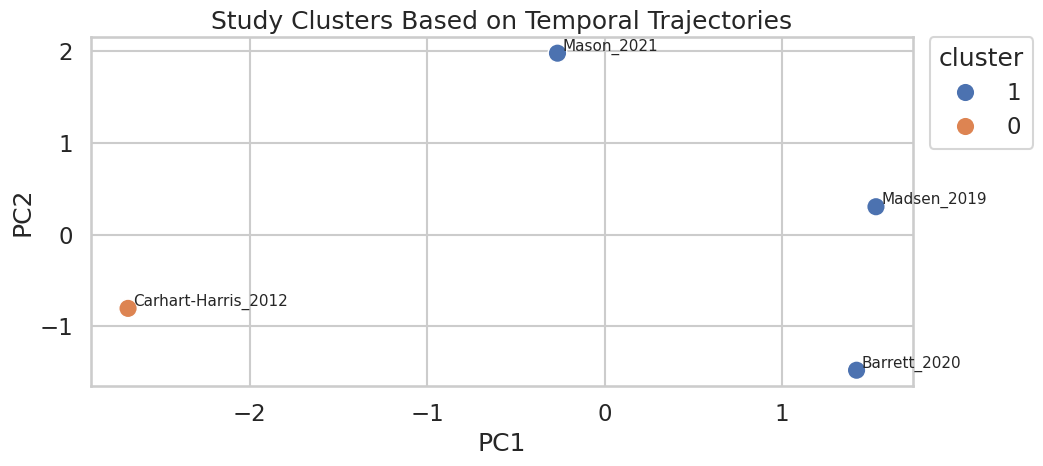

In [8]:
plt.figure(figsize=(11,5))

ax = sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="cluster",
    s=180
)

for _, row in plot_df.iterrows():
    plt.text(row["pc1"] + 0.03, row["pc2"] + 0.03, row["study"], fontsize=11)

ax.legend(
    title="cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Study Clusters Based on Temporal Trajectories")
plt.tight_layout()
plt.savefig("figures/04_study_clusters_pca.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
cluster_table = plot_df[["study", "cluster"]]
cluster_table.to_csv("outputs/04_study_clusters.csv", index=False)
feature_table.to_csv("outputs/04_trajectory_feature_table.csv")

cluster_table

,study,cluster
0,Barrett_2020,1
1,Carhart-Harris_2012,0
2,Madsen_2019,1
3,Mason_2021,1
